Import necessary packages and load required data

In [1]:
# !pip install numpy pandas scikit-learn tensorflow matplotlib seaborn

import pyodbc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix

from keras.models import Model
from keras.layers import Input, Dense, BatchNormalization, Dropout
from keras.optimizers import Adam


In [2]:
# server = "localhost"
# database = "PL-prediction-db"
# username = "lilian"
# password = "12345678"
# driver = "ODBC Driver 17 for SQL Server"
# conn_str = f"Driver={driver};Server=tcp:{server},1433;Database={database};UID={username};PWD={password};Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30"
conn_str = "DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=PL-prediction-db;UID=lilian;PWD=12345678;"


def get_conn():
    return pyodbc.connect(conn_str)


def get_all_fixtures():
    rows = []
    with get_conn() as conn:
        # cursor = conn.cursor()
        # cursor.execute("SELECT * FROM pl.pl_fixtures")

        # for row in cursor.fetchall():
        #     rows.append(f"{row.fixture_id},{row.Season},{row.season_sk},{row.fixture_date},{row.HomeTeam},{row.AwayTeam},{row.FullTimeResults},{row.HomeGoals},{row.AwayGoals},{row.StandingDiff},{row.HomeWins},{row.AwayWins},{row.HomeDraws},{row.AwayDraws},{row.AvgHomeGoals},{row.AvgAwayGoals},{row.AvgHomeShots},{row.AvgAwayShots},{row.AvgHomeShotsOnTarget},{row.AvgAwayShotsOnTarget},{row.AvgHomeCorners},{row.AvgAwayCorners},{row.AvgHomeGoalsConceded},{row.AvgAwayGoalsConceded},{row.AvgHomeShotsConceded},{row.AvgAwayShotsConceded},{row.load_date}")
        # return rows

        query = "SELECT * FROM pl.match_results"
        df = pd.read_sql(query, conn)
    return df
    
df_matches = get_all_fixtures()


C:\Users\tokam\AppData\Local\Temp\ipykernel_23108\1356302608.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
Urls = ["https://github.com/yuliang419/football-predictor/blob/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_processed_results.csv?raw=true", 
        "https://raw.githubusercontent.com/yuliang419/football-predictor/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_Standings.csv?raw=true"]

def getCsv(csvUrl):
    df = pd.read_csv(csvUrl)

    if "results" in csvUrl :
        if "Unnamed: 0" in df.columns:
            df.rename(columns={"Unnamed: 0": "fixture_id"}, inplace=True)

    return df

#df_matches = getCsv(Urls[0])
#df_standings = getCsv(Urls[1])

# print("For results", df_matches.shape, df_matches.isnull().sum())
# print("For standings", df_standings.shape, df_standings.isnull().sum())

# Make a copy of the dataframe to keep things clean
df = df_matches.copy()

Features are selected and we select Full time result as target value

In [4]:
feature_cols = [
	'HT_match_played'
	, 'HT_current_standing'
	, 'HT_past_standing'
	, 'HT_past_goal_diff'
	, 'HT_past_win_rate'
	, 'HT_goal_for'
	, 'HT_goal_against'
	, 'HT_goal_diff'
	, 'HT_win_rate_season'
	, 'AT_match_played'
	, 'AT_current_standing'
	, 'AT_past_standing'
	, 'AT_past_goal_diff'
	, 'AT_past_win_rate'
	, 'AT_goal_for'
	, 'AT_goal_against'
	, 'AT_goal_diff'
	, 'AT_win_rate_season'
	, 'HT_3_win_streak'
	, 'HT_5_win_streak'
	, 'HT_3_lose_Streak'
	, 'HT_5_lose_Streak'
	, 'AT_3_win_streak'
	, 'AT_5_win_streak'
	, 'AT_3_lose_Streak'
	, 'AT_5_lose_Streak'
	, 'HT_5_win_rate'
	, 'AT_5_win_rate'
	, 'current_standing_diff'
	, 'past_standing_diff'
	, 'past_goal_diff_diff'
	, 'past_win_rate_diff'
	, 'win_rate_season_diff'
	, 'goal_diff_diff'
]

X = df[feature_cols].values
y_home = df['FTHG'].values
y_away = df['FTAG'].values

Stratify data to split 80% into training set

In [5]:
X_train, X_test, y_home_train, y_home_test, y_away_train, y_away_test = train_test_split(
    X, y_home, y_away, test_size=0.2, random_state=42
)
# can use a season-wise split

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# scale features to help neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Training set size: (8947, 34)
Test set size: (2237, 34)


Define model with the given parameters and hyper parameters

In [6]:
input_layer = Input(shape=(X_train.shape[1],))

# Shared hidden layers
x = Dense(64, activation='relu')(input_layer)
# x = BatchNormalization()(x)
# x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.2)(x)

# two output layers (linear activation for regression)
home_output = Dense(1, activation='linear', name='home_goals')(x)  # Predicts integer goals
away_output = Dense(1, activation='linear', name='away_goals')(x)

# Create model
model = Model(inputs=input_layer, outputs=[home_output, away_output])

# Compile with separate losses for each output
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={'home_goals': 'mse', 'away_goals': 'mse'},        # Mean Squared Error for regression
    # loss_weights={'home_goals': 0.7, 'away_goals': 0.3},    # Adjust weights
    metrics={'home_goals': 'mae', 'away_goals': 'mae'}      # Mean Absolute Error
)


model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 34)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 64)                   2240      ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 32)                   2080      ['dense[0][0]']               
                                                                                                  
 home_goals (Dense)          (None, 1)                    33        ['dense_1[0][0]']             
                                                                                              

In [7]:
from keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.1,
#     patience=5,
#     min_lr=1e-6
# )

# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight_dict = dict(enumerate(class_weights))

# print("Class weights:", class_weight_dict)

In [8]:
# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=100,  # Increase epochs since we have early stopping
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping, reduce_lr],
#     verbose=1
# )

history = model.fit(
    X_train,
    {'home_goals': y_home_train, 'away_goals': y_away_train},  # Pass both targets
    validation_data=(X_test, {'home_goals': y_home_test, 'away_goals': y_away_test}),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5)]
)

home_pred, away_pred = model.predict(X_test)

# Round to nearest integer (since goals are whole numbers)
home_pred_rounded = np.round(home_pred).flatten()
away_pred_rounded = np.round(away_pred).flatten()

# Compare with true values
results = pd.DataFrame({
    'True_HomeGoals': y_home_test,
    'Pred_HomeGoals': home_pred_rounded,
    'True_AwayGoals': y_away_test,
    'Pred_AwayGoals': away_pred_rounded
})
print(results.head(10))


Epoch 1/50
280/280 [==============================] - 2s 2ms/step - loss: 2.9795 - home_goals_loss: 1.6838 - away_goals_loss: 1.2957 - home_goals_mae: 1.0068 - away_goals_mae: 0.8888 - val_loss: 2.8128 - val_home_goals_loss: 1.6047 - val_away_goals_loss: 1.2081 - val_home_goals_mae: 0.9942 - val_away_goals_mae: 0.8628
Epoch 2/50
280/280 [==============================] - 0s 2ms/step - loss: 2.7311 - home_goals_loss: 1.5455 - away_goals_loss: 1.1855 - home_goals_mae: 0.9763 - away_goals_mae: 0.8505 - val_loss: 2.7602 - val_home_goals_loss: 1.5600 - val_away_goals_loss: 1.2002 - val_home_goals_mae: 0.9728 - val_away_goals_mae: 0.8472
Epoch 3/50
280/280 [==============================] - 0s 1ms/step - loss: 2.6794 - home_goals_loss: 1.5170 - away_goals_loss: 1.1623 - home_goals_mae: 0.9666 - away_goals_mae: 0.8404 - val_loss: 2.7308 - val_home_goals_loss: 1.5575 - val_away_goals_loss: 1.1733 - val_home_goals_mae: 0.9832 - val_away_goals_mae: 0.8487
Epoch 4/50
280/280 [====================

In [9]:
print("HomeGoals MAE:", mean_absolute_error(y_home_test, home_pred))
print("HomeGoals RMSE:", np.sqrt(mean_squared_error(y_home_test, home_pred)))

# AwayGoals evaluation
print("AwayGoals MAE:", mean_absolute_error(y_away_test, away_pred))
print("AwayGoals RMSE:", np.sqrt(mean_squared_error(y_away_test, away_pred)))

HomeGoals MAE: 0.9679503625372877
HomeGoals RMSE: 1.239199399405726
AwayGoals MAE: 0.8595964039043491
AwayGoals RMSE: 1.0820221799541037


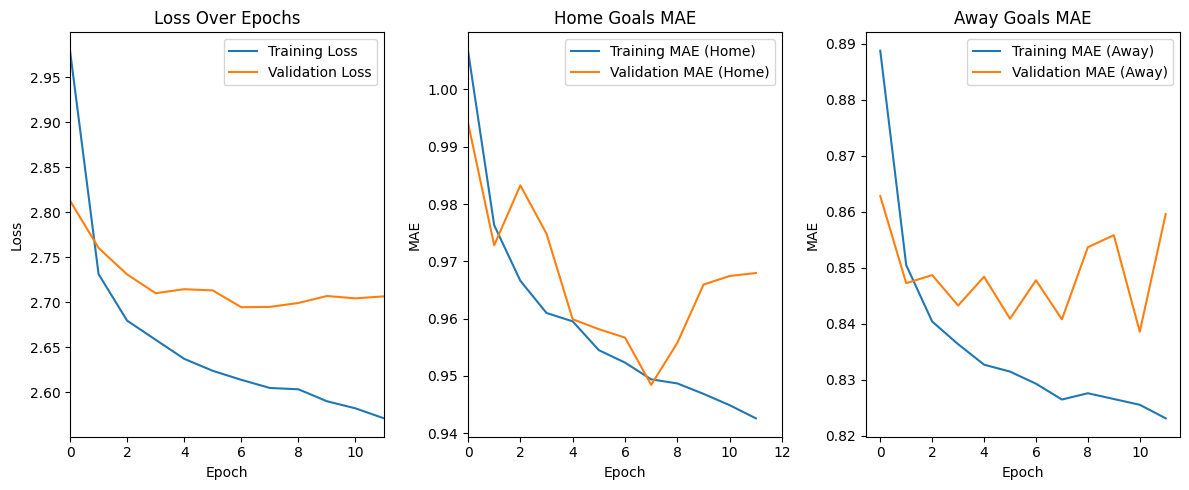

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


# Plot MAE
plt.subplot(1, 3, 2)
plt.plot(history.history['home_goals_mae'], label='Training MAE (Home)')
plt.plot(history.history['val_home_goals_mae'], label='Validation MAE (Home)')
plt.title('Home Goals MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['away_goals_mae'], label='Training MAE (Away)')
plt.plot(history.history['val_away_goals_mae'], label='Validation MAE (Away)')
plt.title('Away Goals MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# test_loss, test_acc = model.evaluate(X_test, y_home_test, verbose=0)
# print("Test Loss: {:.4f}".format(test_loss))
# print("Test Accuracy: {:.2f}%".format(test_acc * 100))

# Evaluate both outputs
test_results = model.evaluate(
    X_test,
    {'home_goals': y_home_test, 'away_goals': y_away_test},
    verbose=0
)

# Print results (order matches compile() metrics)
print("Test Loss (Total): {:.4f}".format(test_results[0]))
print("Home Goals MAE: {:.4f}".format(test_results[3]))  # Index depends on compile() order
print("Away Goals MAE: {:.4f}".format(test_results[4]))

Test Loss (Total): 2.7064
Home Goals MAE: 0.9680
Away Goals MAE: 0.8596


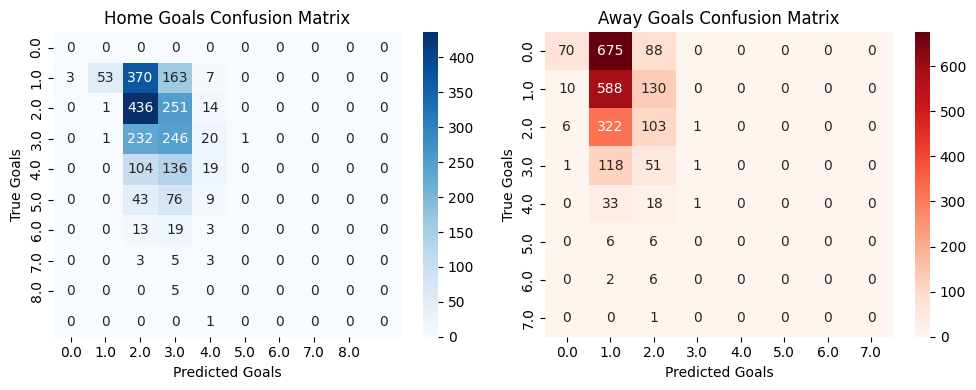

In [52]:
# y_home = df['HomeGoals'].values  # Regression task

# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)  # For classification

# cm = confusion_matrix(y_home_test, y_pred_classes)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
#             xticklabels=sorted(np.unique(y_home)),
#             yticklabels=sorted(np.unique(y_home)))
# plt.title("Home Goals Confusion Matrix")
# plt.xlabel("Predicted Goals")
# plt.ylabel("True Goals")
# plt.show()


# Home Goals Confusion Matrix
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
cm_home = confusion_matrix(y_home_test, home_pred_rounded)
sns.heatmap(cm_home, annot=True, fmt="d", cmap="Blues", 
            xticklabels=sorted(np.unique(y_home_test)),
            yticklabels=sorted(np.unique(y_home_test)))
plt.title("Home Goals Confusion Matrix")
plt.xlabel("Predicted Goals")
plt.ylabel("True Goals")

# Away Goals Confusion Matrix
plt.subplot(1, 2, 2)
cm_away = confusion_matrix(y_away_test, away_pred_rounded)
sns.heatmap(cm_away, annot=True, fmt="d", cmap="Reds", 
            xticklabels=sorted(np.unique(y_away_test)),
            yticklabels=sorted(np.unique(y_away_test)))
plt.title("Away Goals Confusion Matrix")
plt.xlabel("Predicted Goals")
plt.ylabel("True Goals")

plt.tight_layout()
plt.show()

In [53]:
# print("Classification Report:")
# print(classification_report(y_test, y_pred), target_names = [ 'FullTimeResults','HomeGoals','AwayGoals','StandingDiff', 'HomeWins', 'AwayWins','AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded'])

# Home Goals Report
# print("Home Goals Classification Report:")
# print(classification_report(
#     y_home_test, 
#     home_pred_rounded,
#     target_names=[f"Goals_{i}" for i in sorted(np.unique(y_home_test))],
#     digits=4
# ))

# Away Goals Report
print("\nAway Goals Classification Report:")
print(classification_report(
    y_away_test, 
    away_pred_rounded,
    target_names=[f"Goals_{i}" for i in sorted(np.unique(y_away_test))],
    digits=4
))


Away Goals Classification Report:
              precision    recall  f1-score   support

   Goals_0.0     0.8046    0.0840    0.1522       833
   Goals_1.0     0.3372    0.8077    0.4757       728
   Goals_2.0     0.2556    0.2384    0.2467       432
   Goals_3.0     0.3333    0.0058    0.0115       171
   Goals_4.0     0.0000    0.0000    0.0000        52
   Goals_5.0     0.0000    0.0000    0.0000        12
   Goals_6.0     0.0000    0.0000    0.0000         8
   Goals_7.0     0.0000    0.0000    0.0000         1

    accuracy                         0.3406      2237
   macro avg     0.2163    0.1420    0.1108      2237
weighted avg     0.4842    0.3406    0.2600      2237



c:\Users\tokam\Documents\Big Projects\Win 2025\Machine Learning\Premier league prediction\data\PL-prediction-db\PL-Classifier\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\tokam\Documents\Big Projects\Win 2025\Machine Learning\Premier league prediction\data\PL-prediction-db\PL-Classifier\venv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\tokam\Documents\Big Projects\Win 2025\Machine Learning\Premier league prediction\data\PL-prediction-db\PL-Classifier\venv\lib\site-packages\sklearn\m

In [54]:
new_data = df_matches.copy()

# Predict for new data
new_data_scaled = scaler.transform(new_data[feature_cols].values)
home_pred_new, away_pred_new = model.predict(new_data_scaled)
# home_pred_new, away_pred_new = model.predict(new_data_scaled)

# Round to integers and add to DataFrame
new_data['FTHG'] = np.round(home_pred_new).flatten().astype(int)
new_data['FTAG'] = np.round(away_pred_new).flatten().astype(int)

# Save to CSV
new_data.to_csv('match_goals_predictions.csv', index=False)

# Preview
print(new_data[['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']].head())

350/350 [==============================] - 0s 768us/step
      HomeTeam        AwayTeam  FTHG  FTAG
0      Arsenal        Coventry     2     1
1  Aston Villa             QPR     2     1
2      Chelsea       Blackburn     2     1
3    Liverpool  Sheffield Weds     2     1
4     Man City           Leeds     2     1


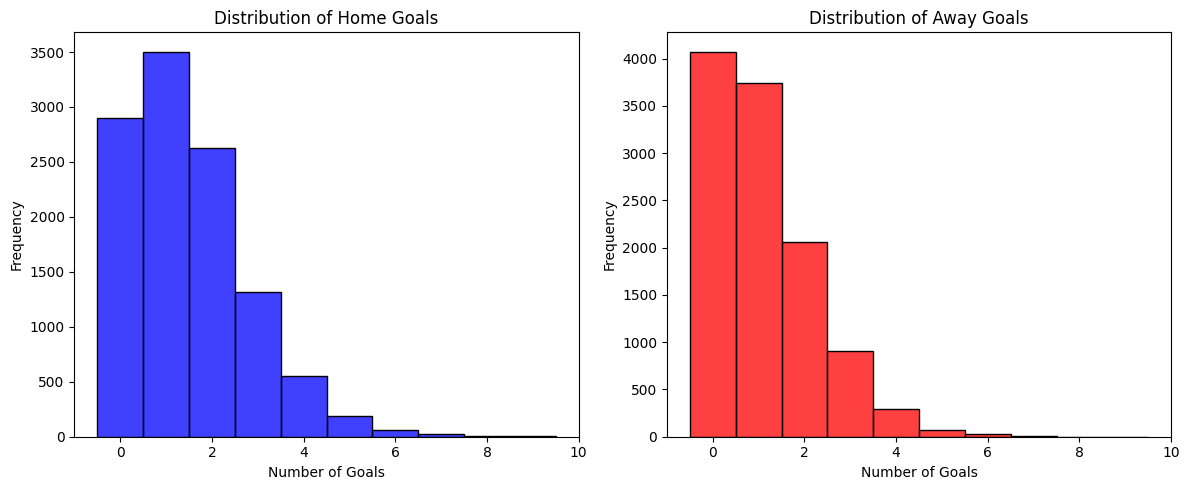

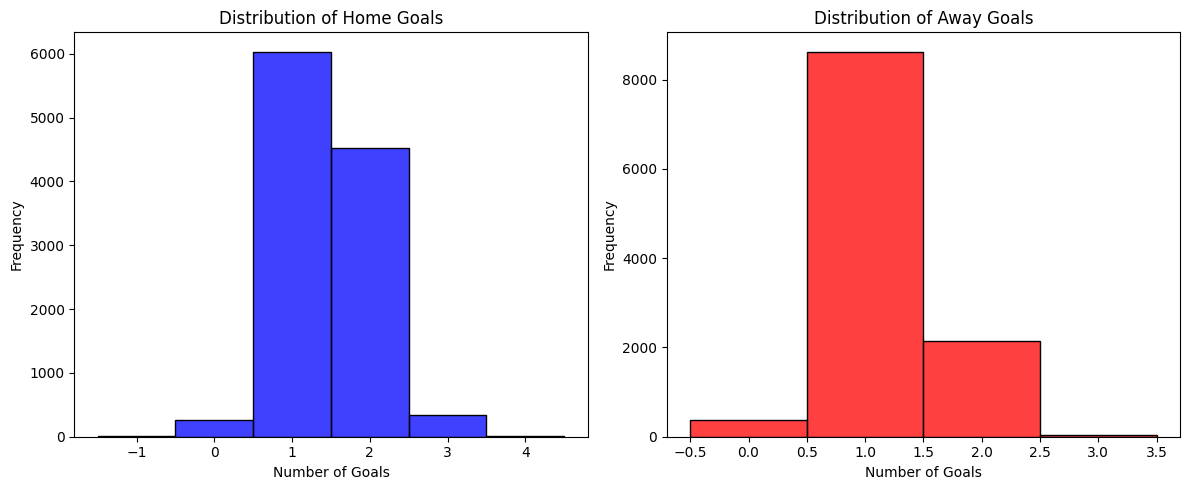

In [55]:
plt.figure(figsize=(12, 5))

# Plot Home Goals
plt.subplot(1, 2, 1)
sns.histplot(df_matches['FTHG'], bins=8, discrete=True, color='blue')  # or any other integer for number of bins
plt.title('Distribution of Home Goals')
plt.xlabel('Number of Goals')
plt.ylabel('Frequency')

# Plot Away Goals
plt.subplot(1, 2, 2)
sns.histplot(df_matches['FTAG'], bins=8, discrete=True, color='red')
plt.title('Distribution of Away Goals')
plt.xlabel('Number of Goals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

# Plot Home Goals
plt.subplot(1, 2, 1)
sns.histplot(new_data['FTHG'], bins=range(0, new_data['FTHG'].max() + 2), discrete=True, color='blue')
plt.title('Distribution of Home Goals')
plt.xlabel('Number of Goals')
plt.ylabel('Frequency')

# Plot Away Goals
plt.subplot(1, 2, 2)
sns.histplot(new_data['FTAG'], bins=range(0, new_data['FTAG'].max() + 2), discrete=True, color='red')
plt.title('Distribution of Away Goals')
plt.xlabel('Number of Goals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
